In [7]:
import numpy as np 
import matplotlib.pyplot as plt

# Bandstop Filter Transformations 

Filter with band edge at $\omega_1, \omega_2$ with center freqeuncy $\omega_0 = \sqrt{\omega_1\omega_2}$ and bandwidth $\Delta = \frac{\omega_2 - \omega_1}{\omega_0}$

The transformation for frequency is 
$\omega \leftarrow \Delta (\frac{\omega}{\omega_0} - \frac{\omega_0}{\omega})^{-1} $

Each series inductance L of low pass response has transformation 
$$L_k = \frac{\Delta L}{\omega_0} \quad \quad \quad C_k = \frac{1}{\omega_0\Delta L}$$
and each series capacitance C has transformation 
$$C_k = \frac{\Delta C}{\omega_0} \quad \quad \quad L_k = \frac{1}{\omega_0\Delta C}$$

In [8]:
# based on L, C transformations, make a function that converts a given L or C values of 
# a low pass filter to a band stop filter with given center frequency and bandwidth 
# based on Each series inductance L of low pass response has transformation 
# $$L_k = \frac{\Delta L}{\omega_0} \quad \quad \quad C_k = \frac{1}{\omega_0\Delta L}$$
# and each series capacitance C has transformation 
# $$C_k = \frac{\Delta C}{\omega_0} \quad \quad \quad L_k = \frac{1}{\omega_0\Delta C}$$
def lp_to_bs_inductor(L, omega_0, delta):
    # Transform series inductor to bandstop equivalents
    L_bs = (delta * L) / omega_0
    C_bs = 1 / (omega_0 * delta * L)
    return L_bs, C_bs

def lp_to_bs_capacitor(C, omega_0, delta):
    # Transform series capacitor to bandstop equivalents
    C_bs = (delta * C) / omega_0
    L_bs = 1 / (omega_0 * delta * C)
    return L_bs, C_bs


# Making Low Pass Filters 
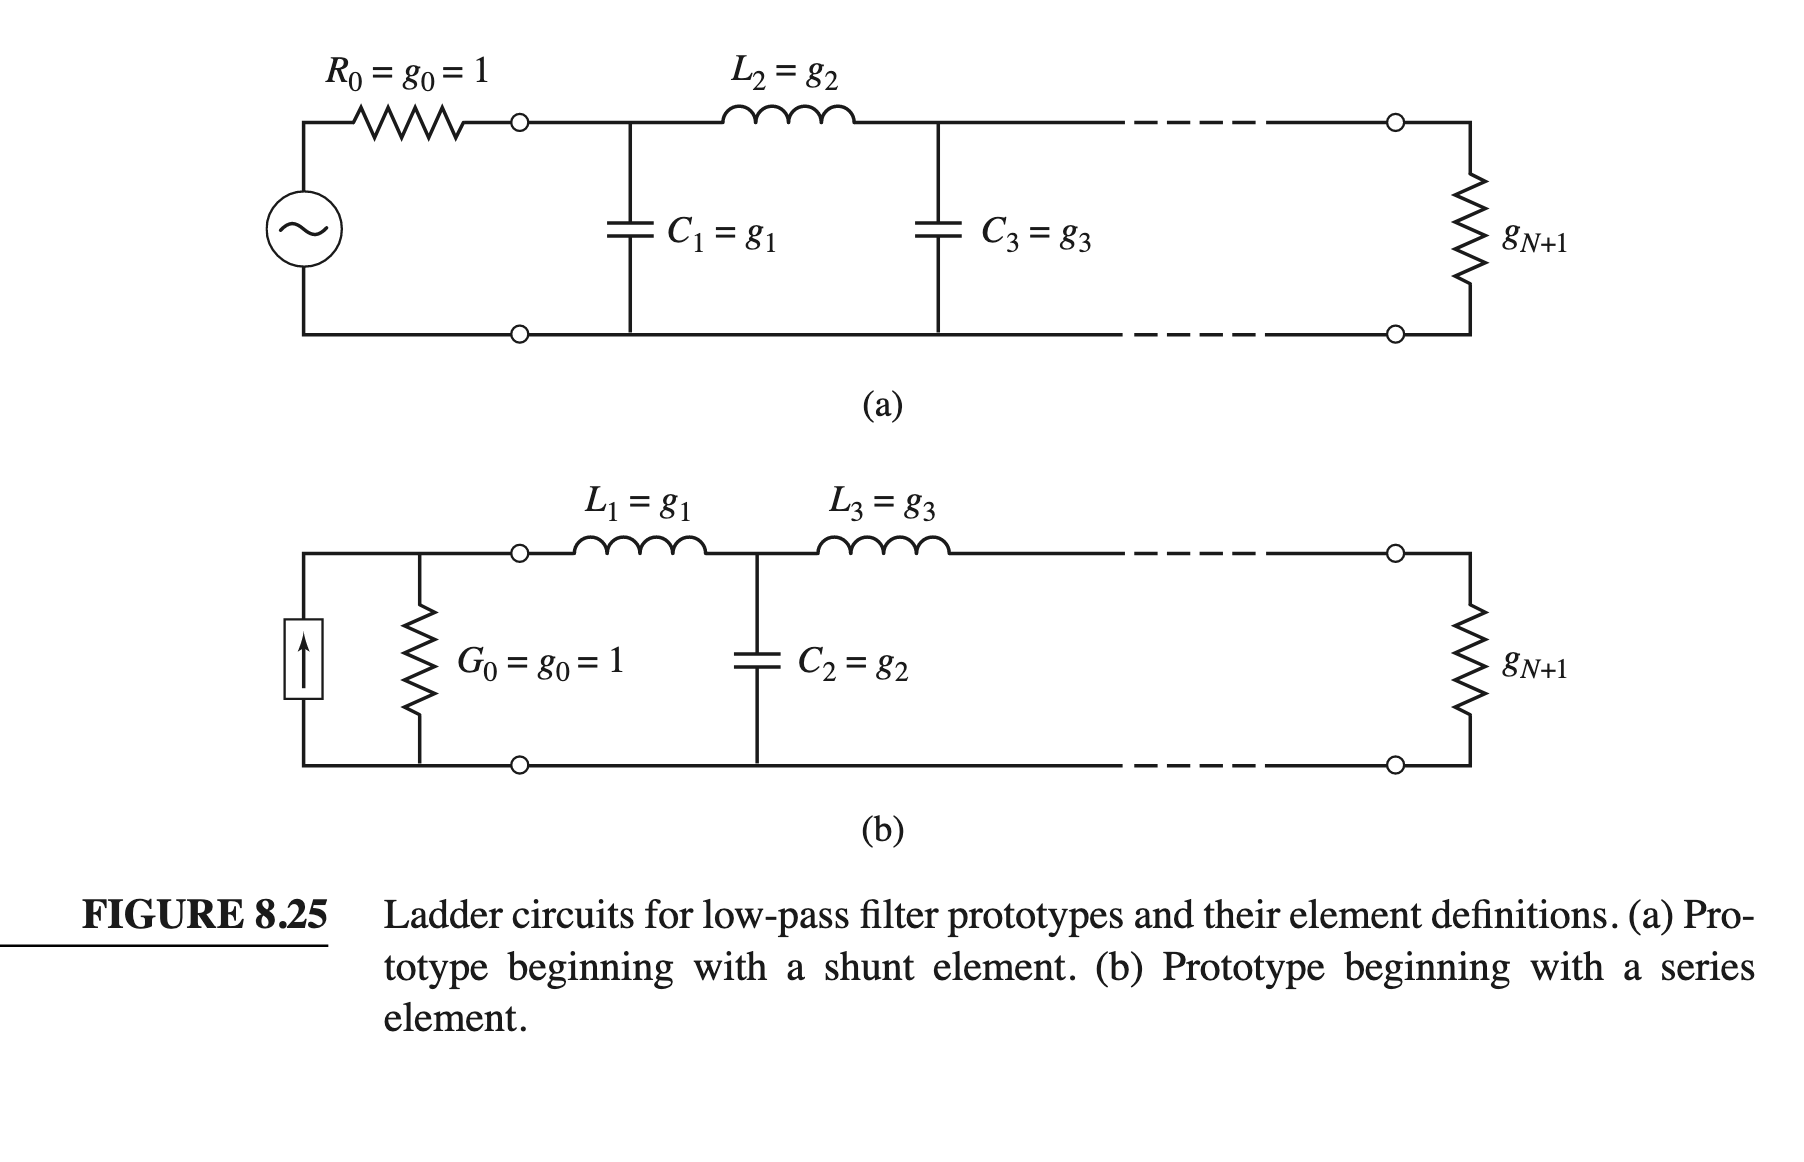

## Choosing Equal ripple 3 db ripple since gives max attenuation for least sections(N) , 
N = 5 gives 30 db attenuation at bandwidth of 0.4

In [9]:
# N =5 Maximum flat low pass 
g0 = 1.0
gs = [3.4817, 0.7618, 4.5381, 0.7618, 3.4817, 1.0000]
gs_full = [g0] + gs
# first g is capacitor , second is an inductor, third is capacitor, fourth is inductor and so on 
Cs = [gs[i] for i in range(0,len(gs),2)]
Ls = [gs[i] for i in range(1,len(gs),2)]

# Impedance scaling 
Z0 = 50
Cs = [C/Z0 for C in Cs]
Ls = [L*Z0 for L in Ls]
print("Capacitors: ", [C for C in Cs])
print("Inductors: ", [L for L in Ls])


Capacitors:  [0.069634, 0.090762, 0.069634]
Inductors:  [38.09, 38.09, 50.0]


In [12]:
# Filter parameters
omega_1 = 3.5e9  # Hz
omega_2 = 7e9
center_freq = np.sqrt(omega_1 * omega_2)
bandwidth = (omega_2 - omega_1)/center_freq
print("Center Frequency (GHz): ", center_freq*1e-9)
print("Bandwidth: ", bandwidth)

Center Frequency (GHz):  4.949747468305834
Bandwidth:  0.7071067811865475


In [13]:
# bandstop filter transformation 
Cs_element = []
Ls_element = []
c_bool = True

# First is. a capcitor, second is inductor and so on 
for element in gs_full:
    if c_bool:
        g_imp_scaled = element / Z0
        L, C = lp_to_bs_capacitor(g_imp_scaled, center_freq*2*np.pi, bandwidth)
        Cs_element.append(C)
        Ls_element.append(L)
    else:
        g_imp_scaled = element * Z0
        L, C = lp_to_bs_inductor(g_imp_scaled, center_freq*2*np.pi, bandwidth)
        Ls_element.append(L)
        Cs_element.append(C)
    c_bool = not c_bool

In [15]:
print("Bandstop Filter Elements:")
for i in range(len(Cs_element)):
    print(f"Element {i+1}: L = {Ls_element[i] *1e9:.6e} nH, C = {Cs_element[i]*1e12:.6e} pF")

Bandstop Filter Elements:
Element 1: L = 2.273642e+00 nH, C = 4.547284e-01 pF
Element 2: L = 3.958070e+00 nH, C = 2.612106e-01 pF
Element 3: L = 2.984566e+00 nH, C = 3.464121e-01 pF
Element 4: L = 5.159007e+00 nH, C = 2.004048e-01 pF
Element 5: L = 2.984566e+00 nH, C = 3.464121e-01 pF
Element 6: L = 3.958070e+00 nH, C = 2.612106e-01 pF
Element 7: L = 2.273642e+00 nH, C = 4.547284e-01 pF
